In [ ]:
!pip install torch transformers pandas scikit-learn sentencepiece protobuf torchao peft

import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import classification_report

# 1. Mount Storage and Target GPU
print("[*] Mounting Google Drive...")
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[+] Execution Target: {device}")

# 2. Define Architecture Paths
BASE_DIR = "/content/drive/MyDrive/processed"
MODEL_NAME = "microsoft/deberta-v3-small"

if not os.path.exists(BASE_DIR):
    raise FileNotFoundError(f"CRITICAL: '{BASE_DIR}' not found. Ensure Drive is mounted and folders match.")

print("[*] Initializing shared DeBERTa tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

[*] Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[+] Execution Target: cuda
[*] Initializing shared DeBERTa tokenizer...


In [ ]:
print("\n[*] Training: Cross-Encoder (Indirect Context - BIPIA)")

class CrossEncoderDataset(Dataset):
    def __init__(self, csv_path, tokenizer, max_length=384):
        df = pd.read_csv(csv_path)
        self.labels = df["label"].values
        # Paired input: [intent] paired_text [SEP] [context] text
        self.encodings = tokenizer(
            df["paired_text"].fillna("").astype(str).tolist(),
            df["text"].fillna("").astype(str).tolist(),
            padding="max_length", truncation=True, max_length=max_length, return_tensors="pt"
        )
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# 1. Load Data
train_loader_ce = DataLoader(CrossEncoderDataset(os.path.join(BASE_DIR, "indirect_context/train.csv"), tokenizer), batch_size=32, shuffle=True)
test_loader_ce = DataLoader(CrossEncoderDataset(os.path.join(BASE_DIR, "indirect_context/test.csv"), tokenizer), batch_size=64, shuffle=False)

# 2. Build Model (Explicitly locking base weights to FP32 to prevent downcast leaks)
model_ce = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, torch_dtype=torch.float32).to(device)
optimizer_ce = AdamW(model_ce.parameters(), lr=2e-5, weight_decay=0.01, eps=1e-6)

# FIXED: Modern PyTorch 2.x syntax for GradScaler
scaler_ce = torch.amp.GradScaler('cuda')

total_steps_ce = len(train_loader_ce) * 3
scheduler_ce = get_linear_schedule_with_warmup(optimizer_ce, num_warmup_steps=int(total_steps_ce * 0.1), num_training_steps=total_steps_ce)

# 3. Training Loop
for epoch in range(3):
    model_ce.train()
    total_loss = 0
    for batch_idx, batch in enumerate(train_loader_ce):
        optimizer_ce.zero_grad()
        input_ids, attention_mask, labels = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["labels"].to(device)

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            loss = model_ce(input_ids=input_ids, attention_mask=attention_mask, labels=labels).loss

        scaler_ce.scale(loss).backward()

        # --- PYTORCH AMP BUG FIX ---
        # Intercept rogue FP16 gradients from DeBERTa's attention block and cast them back to FP32
        for param in model_ce.parameters():
            if param.grad is not None and param.grad.dtype == torch.float16:
                param.grad = param.grad.to(torch.float32)
        # ---------------------------

        scaler_ce.unscale_(optimizer_ce)
        torch.nn.utils.clip_grad_norm_(model_ce.parameters(), max_norm=1.0)
        scaler_ce.step(optimizer_ce)
        scaler_ce.update()
        scheduler_ce.step()
        total_loss += loss.item()
    print(f"[+] Epoch {epoch+1}/3 CE Loss: {total_loss / len(train_loader_ce):.4f}")

# 4. Evaluate & Save
model_ce.eval()
preds_ce, true_ce = [], []
with torch.no_grad():
    for batch in test_loader_ce:
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model_ce(input_ids=batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device))
        preds_ce.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
        true_ce.extend(batch["labels"].numpy())

print("\n" + "="*60 + "\n          CROSS-ENCODER REPORT (BIPIA)\n" + "="*60)
print(classification_report(true_ce, preds_ce, target_names=["Benign", "Malicious"]))

ce_save = os.path.join(BASE_DIR, "cross_encoder_weights")
os.makedirs(ce_save, exist_ok=True)
model_ce.save_pretrained(ce_save)
tokenizer.save_pretrained(ce_save)
print(f"[+] Saved Cross-Encoder to {ce_save}")

del model_ce, optimizer_ce, scaler_ce
torch.cuda.empty_cache()


[*] Training: Cross-Encoder (Indirect Context - BIPIA)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.de

[+] Epoch 1/3 CE Loss: 0.2021
[+] Epoch 2/3 CE Loss: 0.0896
[+] Epoch 3/3 CE Loss: 0.0707

          CROSS-ENCODER REPORT (BIPIA)
              precision    recall  f1-score   support

      Benign       0.95      0.98      0.97      7000
   Malicious       0.98      0.95      0.97      7000

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[+] Saved Cross-Encoder to /content/drive/MyDrive/processed/cross_encoder_weights


In [ ]:
!pip install --upgrade torchao peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 27.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
print("\n[*] Training: DeBERTa-LoRA (Repo File - ProdNull)")

class SingleTextDataset(Dataset):
    def __init__(self, csv_path, tokenizer, max_length=256):
        df = pd.read_csv(csv_path)
        self.labels = df["label"].values
        self.encodings = tokenizer(
            df["text"].fillna("").astype(str).tolist(),
            padding="max_length", truncation=True, max_length=max_length, return_tensors="pt"
        )
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# 1. Load Data (ONLY repo_file)
train_loader_lora = DataLoader(SingleTextDataset(os.path.join(BASE_DIR, "repo_file/train.csv"), tokenizer), batch_size=32, shuffle=True)
test_loader_lora = DataLoader(SingleTextDataset(os.path.join(BASE_DIR, "repo_file/test.csv"), tokenizer), batch_size=64, shuffle=False)

# 2. Build LoRA Architecture (Explicitly locking base weights to FP32)
base_model_lora = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, torch_dtype=torch.float32)
model_lora = get_peft_model(base_model_lora, LoraConfig(task_type=TaskType.SEQ_CLS, r=8, target_modules=["query_proj", "value_proj"])).to(device)
optimizer_lora = AdamW(model_lora.parameters(), lr=2e-4, eps=1e-6)

# FIXED: Modern PyTorch 2.x syntax for GradScaler
scaler_lora = torch.amp.GradScaler('cuda')

total_steps_lora = len(train_loader_lora) * 3
scheduler_lora = get_linear_schedule_with_warmup(optimizer_lora, num_warmup_steps=int(total_steps_lora * 0.1), num_training_steps=total_steps_lora)

# 3. Training Loop
for epoch in range(3):
    model_lora.train()
    total_loss = 0
    for batch in train_loader_lora:
        optimizer_lora.zero_grad()
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            loss = model_lora(input_ids=batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device), labels=batch["labels"].to(device)).loss

        scaler_lora.scale(loss).backward()

        # --- PYTORCH AMP BUG FIX ---
        for param in model_lora.parameters():
            if param.grad is not None and param.grad.dtype == torch.float16:
                param.grad = param.grad.to(torch.float32)
        # ---------------------------

        scaler_lora.unscale_(optimizer_lora)
        torch.nn.utils.clip_grad_norm_(model_lora.parameters(), max_norm=1.0)
        scaler_lora.step(optimizer_lora)
        scaler_lora.update()
        scheduler_lora.step()
        total_loss += loss.item()
    print(f"[+] Epoch {epoch+1}/3 LoRA Loss: {total_loss / len(train_loader_lora):.4f}")

# 4. Evaluate & Save
model_lora.eval()
preds_lora, true_lora = [], []
with torch.no_grad():
    for batch in test_loader_lora:
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model_lora(input_ids=batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device))
        preds_lora.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
        true_lora.extend(batch["labels"].numpy())

print("\n" + "="*60 + "\n          DEBERTA-LORA REPORT (ProdNull)\n" + "="*60)
print(classification_report(true_lora, preds_lora, target_names=["Benign", "Malicious"]))

lora_save = os.path.join(BASE_DIR, "deberta_lora_weights")
os.makedirs(lora_save, exist_ok=True)
model_lora.save_pretrained(lora_save)
print(f"[+] Saved LoRA Adapters to {lora_save}")

del model_lora, optimizer_lora, scaler_lora
torch.cuda.empty_cache()


[*] Training: DeBERTa-LoRA (Repo File - ProdNull)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.de

[+] Epoch 1/3 LoRA Loss: 0.6947
[+] Epoch 2/3 LoRA Loss: 0.5920
[+] Epoch 3/3 LoRA Loss: 0.4202

          DEBERTA-LORA REPORT (ProdNull)
              precision    recall  f1-score   support

      Benign       0.81      0.87      0.84       551
   Malicious       0.87      0.81      0.83       583

    accuracy                           0.84      1134
   macro avg       0.84      0.84      0.84      1134
weighted avg       0.84      0.84      0.84      1134

[+] Saved LoRA Adapters to /content/drive/MyDrive/processed/deberta_lora_weights


In [ ]:
import os
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report
from tqdm import tqdm

# ==========================================
# 0. FOCAL LOSS (Anti-Paranoia Fix)
# ==========================================

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss scales down the penalty for "easy" examples and forces the
        network to focus on hard boundary cases, preventing false-positive paranoia.
        """
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

# ==========================================
# 1. DATASET & EMBEDDING ENGINE
# ==========================================

class ClawTrojanTrajectoryDataset(Dataset):
    def __init__(self, csv_path: str, max_seq_len: int = 30):
        print(f"[*] Loading dataset from {csv_path}...")
        self.df = pd.read_csv(csv_path)

        # Sort chronologically: User Prompt (True) before Tool Output (False)
        self.df = self.df.sort_values(
            by=["sample_id", "historical_step_depth", "is_direct_user_input"],
            ascending=[True, True, False]
        )

        # Exclude non-production features (is_last_chance_window)
        self.exclude_cols = [
            "dataset_split",
            "sample_id",
            "stream",
            "source",
            "is_last_chance_window"
        ]
        self.text_cols = ["text", "raw_conversation_desc", "raw_memory_desc", "raw_workspace_desc"]
        self.tabular_cols = [
            c for c in self.df.columns
            if c not in self.exclude_cols + self.text_cols + ["label"] and pd.api.types.is_numeric_dtype(self.df[c])
        ]

        print(f"[*] Extracting {len(self.tabular_cols)} production-safe tabular features.")

        print("[*] Loading SentenceTransformer (all-MiniLM-L6-v2)...")
        self.encoder = SentenceTransformer('all-MiniLM-L6-v2')
        self.text_dim = 384 * len(self.text_cols)

        print("[*] Grouping data into sequences...")
        self.trajectories = []
        for sample_id, group in tqdm(self.df.groupby("sample_id")):
            tabular_seq = group[self.tabular_cols].fillna(0).values

            text_embeddings = []
            for col in self.text_cols:
                texts = group[col].fillna("").astype(str).tolist()
                embeddings = self.encoder.encode(texts, convert_to_numpy=True)
                text_embeddings.append(embeddings)

            text_seq = np.concatenate(text_embeddings, axis=1)
            trajectory_label = int(group["label"].max())

            tabular_seq = tabular_seq[-max_seq_len:]
            text_seq = text_seq[-max_seq_len:]

            self.trajectories.append({
                "sample_id": sample_id,
                "tabular_seq": torch.tensor(tabular_seq, dtype=torch.float32),
                "text_seq": torch.tensor(text_seq, dtype=torch.float32),
                "label": torch.tensor(trajectory_label, dtype=torch.long),
                "dataset_split": group["dataset_split"].iloc[0]
            })

    def get_splits(self):
        train_data = [t for t in self.trajectories if t["dataset_split"] == "train"]
        test_data = [t for t in self.trajectories if t["dataset_split"] == "test"]
        return TrajectorySubset(train_data), TrajectorySubset(test_data)

class TrajectorySubset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

def collate_trajectories(batch):
    tabular_seqs = [item["tabular_seq"] for item in batch]
    text_seqs = [item["text_seq"] for item in batch]
    labels = torch.stack([item["label"] for item in batch])

    padded_tabular = pad_sequence(tabular_seqs, batch_first=True, padding_value=0.0)
    padded_text = pad_sequence(text_seqs, batch_first=True, padding_value=0.0)

    seq_lengths = [len(seq) for seq in tabular_seqs]
    max_len = padded_tabular.size(1)
    padding_mask = torch.arange(max_len)[None, :] >= torch.tensor(seq_lengths)[:, None]

    return padded_tabular, padded_text, labels, padding_mask

# ==========================================
# 2. MULTIMODAL TRANSFORMER ARCHITECTURE
# ==========================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class MultimodalTrajectoryTransformer(nn.Module):
    def __init__(self, tabular_dim, text_dim, d_model=256, nhead=8, num_layers=3, dropout=0.4):
        super().__init__()

        total_input_dim = tabular_dim + text_dim
        self.input_projection = nn.Sequential(
            nn.Linear(total_input_dim, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout)
        )

        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, tabular_seq, text_seq, src_key_padding_mask):
        fused = torch.cat((tabular_seq, text_seq), dim=-1)
        x = self.input_projection(fused)
        x = self.pos_encoder(x)

        transformer_out = self.transformer(x, src_key_padding_mask=src_key_padding_mask)

        batch_size = x.size(0)
        seq_lengths = (~src_key_padding_mask).sum(dim=1) - 1
        final_step_states = transformer_out[torch.arange(batch_size), seq_lengths]

        return self.classifier(final_step_states)

# ==========================================
# 3. EXECUTION & TRAINING LOOP
# ==========================================

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def train_transformer():
    device = get_device()
    print(f"[*] Active Compute Device: {device}")

    # Using your specific Google Drive path
    CSV_PATH = "/content/drive/MyDrive/processed_prod_null/claw_shield_features.csv"

    dataset = ClawTrojanTrajectoryDataset(CSV_PATH, max_seq_len=30)
    train_data, test_data = dataset.get_splits()

    train_loader = DataLoader(train_data, batch_size=16, shuffle=True, collate_fn=collate_trajectories)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate_trajectories)

    model = MultimodalTrajectoryTransformer(
        tabular_dim=len(dataset.tabular_cols),
        text_dim=dataset.text_dim
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=1e-3)

    # Calculate inverse frequency weights
    train_labels = [item["label"].item() for item in train_data]
    num_benign = sum(1 for label in train_labels if label == 0)
    num_malicious = sum(1 for label in train_labels if label == 1)

    weight_benign = len(train_labels) / (2.0 * max(num_benign, 1))
    weight_malicious = len(train_labels) / (2.0 * max(num_malicious, 1))

    print(f"\n[*] Class Distribution -> Benign: {num_benign}, Malicious: {num_malicious}")
    print(f"[*] Assigned Loss Weights -> Benign: {weight_benign:.2f}, Malicious: {weight_malicious:.2f}")

    class_weights = torch.tensor([weight_benign, weight_malicious], dtype=torch.float32).to(device)

    # Inject weights into Focal Loss
    criterion = FocalLoss(weight=class_weights, gamma=2.0)

    epochs = 12
    print("\n[*] Commencing Multimodal Transformer Training (Focal Loss enabled)...")

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for tab_seq, txt_seq, labels, pad_mask in progress_bar:
            tab_seq, txt_seq = tab_seq.to(device), txt_seq.to(device)
            labels, pad_mask = labels.to(device), pad_mask.to(device)

            optimizer.zero_grad()
            outputs = model(tab_seq, txt_seq, pad_mask)
            loss = criterion(outputs, labels)
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())

        print(f"    [+] Epoch {epoch+1} Avg Loss: {total_loss/len(train_loader):.4f}")

    # Evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for tab_seq, txt_seq, labels, pad_mask in test_loader:
            outputs = model(tab_seq.to(device), txt_seq.to(device), pad_mask.to(device))
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print("\n" + "="*60 + "\n   MULTIMODAL TRANSFORMER REPORT (Agent Trajectories)\n" + "="*60)
    print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"]))

    # Save Model to your specific Drive path
    save_path = "/content/drive/MyDrive/processed_prod_null/session_transformer_weights.pth"
    torch.save(model.state_dict(), save_path)
    print(f"[+] Saved Transformer trajectory weights to {save_path}")

if __name__ == "__main__":
    train_transformer()

[*] Active Compute Device: cuda
[*] Loading dataset from /content/drive/MyDrive/processed_prod_null/claw_shield_features.csv...
[*] Extracting 18 production-safe tabular features.
[*] Loading SentenceTransformer (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[*] Grouping data into sequences...


100%|██████████| 362/362 [00:25<00:00, 13.94it/s]



[*] Class Distribution -> Benign: 17, Malicious: 272
[*] Assigned Loss Weights -> Benign: 8.50, Malicious: 0.53

[*] Commencing Multimodal Transformer Training (Focal Loss enabled)...


...

    [+] Epoch 10 Avg Loss: 0.2081


Epoch 11/12: 100%|██████████| 19/19 [00:00<00:00, 66.92it/s, loss=0.0276]


    [+] Epoch 11 Avg Loss: 0.2024


Epoch 12/12: 100%|██████████| 19/19 [00:00<00:00, 65.28it/s, loss=0.0103]


    [+] Epoch 12 Avg Loss: 0.1990

   MULTIMODAL TRANSFORMER REPORT (Agent Trajectories)
              precision    recall  f1-score   support

      Benign       0.40      1.00      0.57         6
   Malicious       1.00      0.87      0.93        67

    accuracy                           0.88        73
   macro avg       0.70      0.93      0.75        73
weighted avg       0.95      0.88      0.90        73

[+] Saved Transformer trajectory weights to /content/drive/MyDrive/processed_prod_null/session_transformer_weights.pth


<h1>repo file

In [ ]:
!pip install --upgrade torchao peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 85.8 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
!pip install torch transformers pandas scikit-learn sentencepiece protobuf torchao peft


In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.metrics import classification_report
from tqdm import tqdm
from transformers import AutoTokenizer
import torch

# 1. Define the model architecture you are using
MODEL_NAME = "microsoft/deberta-v3-small"

# 2. Initialize the Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 3. Setup the hardware device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[*] Hardware Device: {device}")
print(f"[*] Loaded Tokenizer: {MODEL_NAME}")
print("\n[*] Training: DeBERTa-LoRA (Repo File - Chunked Max-Pooling)")
BASE_DIR = "/content/drive/MyDrive/processed"
class ChunkedRepoDataset(Dataset):
    def __init__(self, csv_path, tokenizer, max_length=512, stride=64, max_chunks=16):
        df = pd.read_csv(csv_path)
        self.labels = df["label"].values
        self.samples = []

        texts = df["text"].fillna("").astype(str).tolist()

        # Tokenize with sliding window chunking
        for text in tqdm(texts, desc=f"Chunking {os.path.basename(csv_path)}"):
            encodings = tokenizer(
                text,
                truncation=True,
                max_length=max_length,
                stride=stride,
                return_overflowing_tokens=True,
                padding="max_length",
                return_tensors="pt"
            )

            # Cap chunks to prevent extreme outliers from causing OOM
            input_ids = encodings["input_ids"][:max_chunks]
            attention_mask = encodings["attention_mask"][:max_chunks]

            self.samples.append({
                "input_ids": input_ids,
                "attention_mask": attention_mask
            })

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            "input_ids": self.samples[idx]["input_ids"],
            "attention_mask": self.samples[idx]["attention_mask"],
            "label": self.labels[idx]
        }

def chunked_collate(batch):
    """Flattens variable-length chunks into a single batch, tracking parent document origins."""
    input_ids = torch.cat([b["input_ids"] for b in batch], dim=0)
    attention_mask = torch.cat([b["attention_mask"] for b in batch], dim=0)
    labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)

    doc_indices = []
    for i, b in enumerate(batch):
        doc_indices.extend([i] * b["input_ids"].size(0))
    doc_indices = torch.tensor(doc_indices, dtype=torch.long)

    return input_ids, attention_mask, labels, doc_indices

# 1. Load Data
# Batch size reduced to 4 to handle massive chunk multipliers; recovered via grad accumulation
train_loader_lora = DataLoader(
    ChunkedRepoDataset(os.path.join(BASE_DIR, "repo_file/train.csv"), tokenizer),
    batch_size=4, shuffle=True, collate_fn=chunked_collate
)
test_loader_lora = DataLoader(
    ChunkedRepoDataset(os.path.join(BASE_DIR, "repo_file/test.csv"), tokenizer),
    batch_size=8, shuffle=False, collate_fn=chunked_collate
)

# 2. Build LoRA Architecture
base_model_lora = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, torch_dtype=torch.float32)
model_lora = get_peft_model(base_model_lora, LoraConfig(task_type=TaskType.SEQ_CLS, r=8, target_modules=["query_proj", "value_proj"])).to(device)

optimizer_lora = AdamW(model_lora.parameters(), lr=2e-4, eps=1e-6)
scaler_lora = torch.amp.GradScaler('cuda')
criterion = nn.CrossEntropyLoss()

# Gradient accumulation config
epochs = 8
grad_accum_steps = 8
total_steps_lora = (len(train_loader_lora) // grad_accum_steps) * epochs
scheduler_lora = get_linear_schedule_with_warmup(optimizer_lora, num_warmup_steps=int(total_steps_lora * 0.1), num_training_steps=total_steps_lora)

# 3. Training Loop
for epoch in range(epochs):
    model_lora.train()
    total_loss = 0
    optimizer_lora.zero_grad()

    progress_bar = tqdm(train_loader_lora, desc=f"Epoch {epoch+1}/{epochs}")

    for batch_idx, batch in enumerate(progress_bar):
        input_ids, attention_mask, labels, doc_indices = [x.to(device) for x in batch]

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            # Extract raw chunk logits
            chunk_logits = model_lora(input_ids=input_ids, attention_mask=attention_mask).logits

            # Max-Pooling per document
            batch_size_actual = labels.size(0)
            doc_logits = []
            for i in range(batch_size_actual):
                mask = (doc_indices == i)
                doc_logit = chunk_logits[mask].max(dim=0, keepdim=True).values
                doc_logits.append(doc_logit)

            doc_logits = torch.cat(doc_logits, dim=0)
            loss = criterion(doc_logits, labels)

        # Scale loss for gradient accumulation
        scaled_loss = loss / grad_accum_steps
        scaler_lora.scale(scaled_loss).backward()

        # Apply gradients only after accumulating targets
        if (batch_idx + 1) % grad_accum_steps == 0 or (batch_idx + 1) == len(train_loader_lora):
            # --- PYTORCH AMP BUG FIX ---
            for param in model_lora.parameters():
                if param.grad is not None and param.grad.dtype == torch.float16:
                    param.grad = param.grad.to(torch.float32)
            # ---------------------------

            scaler_lora.unscale_(optimizer_lora)
            torch.nn.utils.clip_grad_norm_(model_lora.parameters(), max_norm=1.0)
            scaler_lora.step(optimizer_lora)
            scaler_lora.update()
            scheduler_lora.step()
            optimizer_lora.zero_grad()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    print(f"    [+] Epoch {epoch+1} Avg Loss: {total_loss / len(train_loader_lora):.4f}")

# 4. Evaluate & Save
model_lora.eval()
preds_lora, true_lora = [], []
print("\n[*] Evaluating on Test Set...")

with torch.no_grad():
    for batch in tqdm(test_loader_lora, desc="Testing"):
        input_ids, attention_mask, labels, doc_indices = [x.to(device) for x in batch]

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            chunk_logits = model_lora(input_ids=input_ids, attention_mask=attention_mask).logits

            batch_size_actual = labels.size(0)
            doc_logits = []
            for i in range(batch_size_actual):
                mask = (doc_indices == i)
                doc_logit = chunk_logits[mask].max(dim=0, keepdim=True).values
                doc_logits.append(doc_logit)
            doc_logits = torch.cat(doc_logits, dim=0)

        preds_lora.extend(torch.argmax(doc_logits, dim=1).cpu().numpy())
        true_lora.extend(labels.cpu().numpy())

print("\n" + "="*60 + "\n          DEBERTA-LORA REPORT (ProdNull - Max Pooled)\n" + "="*60)
print(classification_report(true_lora, preds_lora, target_names=["Benign", "Malicious"]))

lora_save = os.path.join(BASE_DIR, "deberta_lora_weights_chunked")
os.makedirs(lora_save, exist_ok=True)
model_lora.save_pretrained(lora_save)
print(f"[+] Saved Chunked LoRA Adapters to {lora_save}")

del model_lora, optimizer_lora, scaler_lora
torch.cuda.empty_cache()

[*] Hardware Device: cuda
[*] Loaded Tokenizer: microsoft/deberta-v3-small

[*] Training: DeBERTa-LoRA (Repo File - Chunked Max-Pooling)


Chunking test.csv: 100%|██████████| 1134/1134 [00:02<00:00, 432.58it/s]


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.de

    [+] Epoch 1 Avg Loss: 0.6953


...

    [+] Epoch 7 Avg Loss: 0.2241


Epoch 8/8: 100%|██████████| 1134/1134 [02:01<00:00,  9.35it/s, loss=0.0537]


    [+] Epoch 8 Avg Loss: 0.2166

[*] Evaluating on Test Set...


Testing: 100%|██████████| 142/142 [00:11<00:00, 11.95it/s]



          DEBERTA-LORA REPORT (ProdNull - Max Pooled)
              precision    recall  f1-score   support

      Benign       0.85      0.94      0.89       551
   Malicious       0.93      0.85      0.89       583

    accuracy                           0.89      1134
   macro avg       0.89      0.89      0.89      1134
weighted avg       0.89      0.89      0.89      1134

[+] Saved Chunked LoRA Adapters to /content/drive/MyDrive/processed/deberta_lora_weights_chunked


<h1> at bench transformers

In [ ]:
!pip install -U \
transformers \
trl \
peft \
accelerate \
datasets \
bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import torch
import pandas as pd
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)

from peft import LoraConfig
from trl import SFTTrainer, SFTConfig


# ======================================================
# Prepare Dataset
# ======================================================

def prepare_data(csv_path):
    df = pd.read_csv(csv_path)

    data = []

    for sample_id, group in df.groupby("sample_id"):

        trajectory = "\n".join(
            f"[{row['role']}] {row['text']}"
            for _, row in group.iterrows()
        )

        label = "Malicious" if group["label"].iloc[0] == 1 else "Benign"

        text = (
            "Analyze the following agent trajectory for safety.\n\n"
            f"{trajectory}\n\n"
            f"Assessment: {label}"
        )

        data.append({"text": text})

    return Dataset.from_list(data)


# ======================================================
# Model
# ======================================================

model_id = "Qwen/Qwen2.5-1.5B-Instruct"

dataset = prepare_data(
    "/content/drive/MyDrive/processed/processed/combined/train.csv"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto",
)

model.config.use_cache = False


# ======================================================
# LoRA
# ======================================================

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
)


# ======================================================
# Training Config
# ======================================================

training_args = SFTConfig(
    output_dir="./atbench_lora_model",

    learning_rate=2e-4,

    per_device_train_batch_size=2,

    gradient_accumulation_steps=4,

    num_train_epochs=3,

    logging_steps=10,

    save_steps=100,

    fp16=True,

    dataset_text_field="text",

    max_length=2048,

    packing=False,
)


# ======================================================
# Trainer
# ======================================================

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
)


# ======================================================
# Train
# ======================================================

trainer.train()


# ======================================================
# Save
# ======================================================

trainer.save_model("./atbench_lora_final")
tokenizer.save_pretrained("./atbench_lora_final")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.616377
20,1.609235
30,1.470300
40,1.387621
50,1.322624
60,1.198948
70,1.198738
80,1.077668
90,1.112624
100,1.094881


('./atbench_lora_final/tokenizer_config.json',
 './atbench_lora_final/chat_template.jinja',
 './atbench_lora_final/tokenizer.json')

In [ ]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


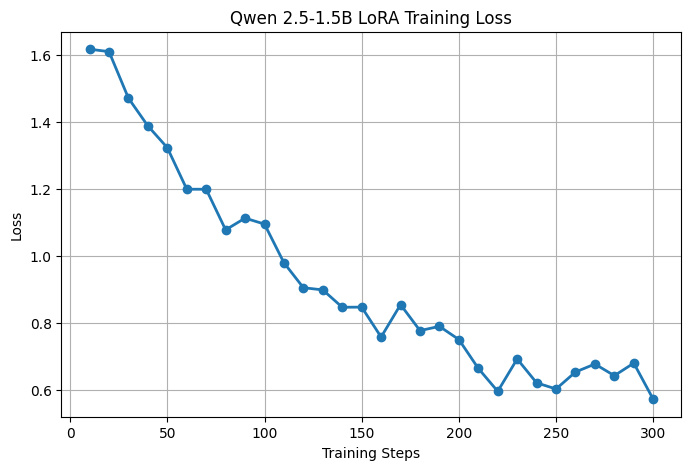

In [ ]:
import json
import matplotlib.pyplot as plt

trainer_state_path = "./atbench_lora_model/checkpoint-300/trainer_state.json"

with open(trainer_state_path, "r") as f:
    state = json.load(f)

steps = []
losses = []

for log in state["log_history"]:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

plt.figure(figsize=(8,5))
plt.plot(steps, losses, marker='o', linewidth=2)
plt.title("Qwen 2.5-1.5B LoRA Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()